# <font color=#0099CC>**MLP: V_in = 90, V_out = 90**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo de este cuaderno**</font>

Notebook individual para una única combinación del grid 4×4 (**V_in=90**, **V_out=90**). Patrón «1 notebook = 1 combo»: se entrena el **MLP** con esa pareja de ventanas y se guarda un resultado parcial y la curva de entrenamiento. El consolidado de los 16 parciales y los heatmaps los genera el agregador correspondiente del modelo.

Los datos son **log-retornos** multivariantes (23 activos del S&P 500); el MAE se interpreta en esa escala. Las features se estandarizan dentro de `get_partitions(..., scaler='standard')` ajustando el `StandardScaler` **solo sobre el train** (sin data-leakage).

**Salidas generadas**:
- `08_results/tablas/parciales/mlp_vin90_vout90.csv` (métricas oficiales tras `load_weights` del best checkpoint).
- `08_results/curvas/mlp/mlp_vin90_vout90.png` (curva train/val con líneas horizontales del MAE val de los **baselines** si existen los CSV en `08_results/tablas/`).
- `08_results/runs/mlp/mlp_vin90_vout90/` (auditoría `BestRunTracker`: `last.json`, `best.json`, `history.csv`, `epoch_history.csv`, `best.keras` histórico; **no sustituye** el flujo oficial de checkpoints `.weights.h5`).

La partición train/val/test es **aleatoria con semilla fija** (`random_state=42` para el split competición, `random_state=123` para el split interno train/val): **no modificar**. Para otra combinación: duplicar este notebook y cambiar **solo** `V_IN` y `V_OUT` en la sección de configuración.

## <font color=#0099CC>**1. ENTORNO DE EJECUCIÓN**</font>

### <font color=#336699>**1.1. Detección Colab / local y rutas del proyecto**</font>

Se configura `BASE`, el acceso a Drive cuando aplica y el `sys.path` para importar utilidades compartidas sin duplicar código.

In [1]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

> Entorno : local
> BASE    : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX
> SRC     : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX\01_src_compartido


## <font color=#0099CC>**2. IMPORTACIONES**</font>

### <font color=#336699>**2.1. Librerías y módulos compartidos**</font>

Stack numérico, TensorFlow/Keras y utilidades de datos y métricas; se inyecta `BASE` en `metrics_utils` antes de cualquier guardado.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import (
    calc_mae_all,
    plot_curva,
    guardar_resultado_parcial,
    BestRunTracker,
    resumen_vs_baselines,
)

print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}')

> TensorFlow : 2.21.0
> GPU        : []


## <font color=#0099CC>**3. CONFIGURACIÓN DEL EXPERIMENTO**</font>

### <font color=#336699>**3.1. Combinación de ventanas e hiperparámetros**</font>

Única celda que cambia al duplicar el notebook para otro par **V_in / V_out**.

In [3]:
MODELO = 'MLP'
V_IN, V_OUT = 90, 90

EPOCHS     = 5000
BATCH_SIZE = 100
PATIENCE   = 1000
SCALER     = 'standard'   # None | 'standard' | 'minmax'  (fit solo sobre X_tr)

N_ASSETS = len(TICKERS)

print(f'> Combinación: V_in={V_IN}, V_out={V_OUT}  |  scaler={SCALER}')

> Combinación: V_in=90, V_out=90  |  scaler=standard


## <font color=#0099CC>**4. DESCARGA DE DATOS**</font>

### <font color=#336699>**4.1. Serie multivariante, ventanas y particionado**</font>

Precios de cierre ajustados de los 23 activos vía `yfinance`, transformados a log-retornos. Se construyen las ventanas para esta combinación y se particiona con la semilla oficial de la competición. El `StandardScaler` se ajusta **solo sobre `X_tr`** y se aplica a train / val / test (`Y` no se escala).

In [4]:
data, df = load_data(use_log_returns=True)
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

X, Y = create_dataset(data, V_IN, V_OUT, verbose=True)

# get_partitions con scaler integrado: fit SOLO con X_tr (sin data-leakage).
# Y queda sin escalar → el MAE es directamente comparable con baselines.
X_tr, X_val, X_test, Y_tr, Y_val, Y_test, scaler = get_partitions(
    X, Y, scaler=SCALER, return_scaler=True, verbose=True,
)

print(f'> Shapes: X_tr {X_tr.shape}  X_val {X_val.shape}  X_test {X_test.shape}')
print(f'         Y_tr {Y_tr.shape}  Y_val {Y_val.shape}  Y_test {Y_test.shape}')

> Datos : 16,197 días × 23 activos
> Rango : 1962-01-03 → 2026-05-12
> Dataset creado — X: (16018, 90, 23), Y: (16018, 23)
> Scaler: standard fitted on X_tr only — applied to train/val/test
> Particiones — Train:  12974  Val:   1442  Test:   1602
> Shapes: X_tr (12974, 90, 23)  X_val (1442, 90, 23)  X_test (1602, 90, 23)
         Y_tr (12974, 23)  Y_val (1442, 23)  Y_test (1602, 23)


## <font color=#0099CC>**5. MODELO MLP**</font>

### <font color=#336699>**5.1. Arquitectura y compilación**</font>

Red densa: la entrada `(V_IN, 23)` se aplana y se procesan con dos capas Dense ocultas con regularización L2 y Dropout. La salida tiene 23 neuronas (un MAE por activo). Loss y métrica: `mae`.

In [5]:
# Base MLP: Flatten + 2 Dense ocultas + Dense(N_ASSETS).
# Edita libremente unidades / dropout / regularización.

def build_mlp(v_in, n_assets=N_ASSETS,
              units_1=256, units_2=128,
              dropout=0.20,
              l2_reg=1e-4,
              learning_rate=1e-3):
    l2 = regularizers.l2(l2_reg)
    model = keras.Sequential([
        layers.Input(shape=(v_in, n_assets)),
        layers.Flatten(),
        layers.Dense(units_1, activation='relu', kernel_regularizer=l2),
        layers.Dropout(dropout),
        layers.Dense(units_2, activation='relu', kernel_regularizer=l2),
        layers.Dropout(dropout),
        layers.Dense(n_assets),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae'],
    )
    return model

model = build_mlp(V_IN)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2070)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 566,039 (2.16 MB)

 Trainable params: 566,039 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

## <font color=#0099CC>**6. ENTRENAMIENTO**</font>

### <font color=#336699>**6.1. Ajuste con callbacks**</font>

- `EarlyStopping` con `restore_best_weights` (corta el entrenamiento si `val_loss` no mejora en `PATIENCE` épocas).
- `ReduceLROnPlateau` cuando `val_loss` se estanca.
- `ModelCheckpoint` guarda **solo los pesos** del best epoch en `08_results/checkpoints/...weights.h5`.
- `BestRunTracker` (de `metrics_utils`) añade auditoría histórica en `08_results/runs/...` sin alterar el cierre oficial del entrenamiento (**siempre** `load_weights` desde `CKPT_PATH` al final).

Una sola combinación (sin bucle 4×4).

In [ ]:
CKPT_DIR = os.path.join(BASE, '08_results', 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(
    CKPT_DIR,
    f'{MODELO.lower()}_vin{V_IN}_vout{V_OUT}_best.weights.h5',
)

es = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=max(5, PATIENCE // 3),
    min_lr=1e-7,
    verbose=1,
)

mcp = ModelCheckpoint(
    filepath=CKPT_PATH,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

# Auditoría histórica (no toca el flujo oficial de checkpoints .h5)
run_tracker = BestRunTracker(
    MODELO, V_IN, V_OUT,
    datasets=(X_tr, Y_tr, X_val, Y_val, X_test, Y_test),
    hparams_extra={
        'epochs':                       EPOCHS,
        'batch_size':                   BATCH_SIZE,
        'patience_early_stopping':      PATIENCE,
        'patience_reduce_lr_plateau':   max(5, PATIENCE // 3),
        'scaler':                       SCALER,
        'weights_checkpoint':           CKPT_PATH,
    },
    auto_plot=False,
)

history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr, mcp, run_tracker],
    verbose=1,
)

# Restaurar los mejores pesos según val_loss (flujo oficial).
model.load_weights(CKPT_PATH)

print(f'> Epochs entrenadas        : {len(history.history["loss"])}')
print(f'> Best val_loss (MAE)      : {min(history.history["val_loss"]):.5f}')
print(f'> Pesos del modelo (best)  : {CKPT_PATH}')

## <font color=#0099CC>**7. MÉTRICAS Y PERSISTENCIA**</font>

### <font color=#336699>**7.1. MAE por partición, comparativa con baselines y guardado**</font>

MAE en train, val y test sobre el modelo ya restaurado al best checkpoint; se imprime la curva con las líneas del MAE val de los baselines (`buy_and_hold`, `trivial`, `lineal`) cuando existen sus CSV. Se imprime también la tabla `resumen_vs_baselines` con el % de mejora del modelo en test. Finalmente se persiste el CSV parcial (una fila) que después consolida `_agregador_*.ipynb`.

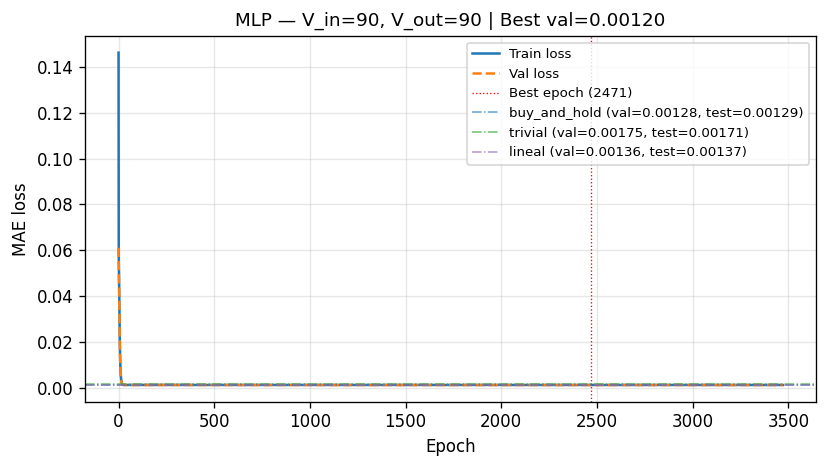

> Comparativa MAE — V_in=90, V_out=90


baseline,n_params,mae_train,mae_val,mae_test,mejora_test_%
MLP,"566,039",0.00123,0.00120,0.00122,—
buy_and_hold,0,0.00130,0.00128,0.00129,+6.02%
trivial,0,0.00175,0.00175,0.00171,+29.03%
lineal,"47,633",0.00114,0.00136,0.00137,+11.37%



> Resultado parcial guardado: c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX\08_results\tablas\parciales\mlp_vin90_vout90.csv

> MAE   train=0.00123   val=0.00120   test=0.00122   |   params=566,039


In [7]:
maes = calc_mae_all(model, X_tr, Y_tr, X_val, Y_val, X_test, Y_test)

# Curva train/val + líneas horizontales de MAE val de los baselines
# (si los CSV de 08_results/tablas existen).
plot_curva(history, MODELO, V_IN, V_OUT, save=True, mostrar_baselines=True)
plt.show()

# Tabla comparativa MAE modelo vs baselines (train/val/test + % mejora).
resumen_vs_baselines(maes, V_IN, V_OUT, nombre_modelo=MODELO, n_params=model.count_params(), verbose=True)

resultado = {
    'modelo':    MODELO,
    'v_in':      V_IN,
    'v_out':     V_OUT,
    'n_params':  model.count_params(),
    'mae_train': maes['train'],
    'mae_val':   maes['val'],
    'mae_test':  maes['test'],
}

ruta = guardar_resultado_parcial(resultado, MODELO, V_IN, V_OUT, verbose=True)

print(f'\n> MAE   train={maes["train"]:.5f}   val={maes["val"]:.5f}   test={maes["test"]:.5f}'
      f'   |   params={model.count_params():,}')

## <font color=#0099CC>**8. CONSOLIDACIÓN 4×4**</font>

### <font color=#336699>**8.1. Heatmaps y tabla global**</font>

Los mapas de calor MAE y la tabla completa del modelo **MLP** sobre todas las combinaciones no se generan aquí; ejecutar el agregador (`_agregador_mlp.ipynb`) cuando existan los 16 CSV parciales en `08_results/tablas/parciales/`.